In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import json
import os

np.random.seed(0)

from methods import (
    CVXPYEstimator,
    
    # FISTAEstimator, 
    # ProjectedGDEstimator,
    # ProximalGDEstimator,

    # ProximalAdaGradEstimator
    # ProximalNewtonEstimator,
    # ProximalNewtonScaledDiagonalCDEstimator,
    # ProximalNewtonLBFGSEstimator,
    
    # TrendFilteringADMMEstimator,
    # TrendFilteringCVXPYEstimator
)

from utils import (
    TruncatedNormal,
    TruncatedGMM,
    Sinusoidal,
    StepFunction,
    
    plot_density,
)

def serialize_dict_to_json(estimator_result_dict: dict) -> dict:
    """Serialize estimator results to a dictionary. (for things like numpy arrays and pandas objects)"""
    serialized_results = {}
    for key, value in estimator_result_dict.items():
        if isinstance(value, np.ndarray):
            serialized_results[key] = value.tolist()
        elif isinstance(value, (np.integer, np.int64)):
            serialized_results[key] = int(value)
        elif isinstance(value, (np.floating, np.float64)):
            serialized_results[key] = float(value)
        # support pandas Series
        elif isinstance(value, pd.Series):
            serialized_results[key] = value.tolist()
        # support pandas DataFrame
        elif isinstance(value, pd.DataFrame):
            serialized_results[key] = value.to_dict(orient='list')
        else:
            serialized_results[key] = value
    return serialized_results

In [2]:
n_samples = 400

sampler_params = {
    'mean': 0.5,
    'std': 0.1,
    'lower': 0,
    'upper': 1
}


# sampler_params = {
#         "sampler_name": "TruncatedGMMFiveSpikes",
#         "sampler_setup": {
#             "sampler": "TruncatedGMM",
#             "sampler_params": {
#                 "components": [
#                     {
#                         "mean": 0.45,
#                         "std": 0.005,
#                         "lower": 0,
#                         "upper": 1
#                     },
#                     {
#                         "mean": 0.475,
#                         "std": 0.005,
#                         "lower": 0,
#                         "upper": 1
#                     },
#                     {
#                         "mean": 0.5,
#                         "std": 0.005,
#                         "lower": 0,
#                         "upper": 1
#                     },
#                     {
#                         "mean": 0.525,
#                         "std": 0.005,
#                         "lower": 0,
#                         "upper": 1
#                     },
#                     {
#                         "mean": 0.55,
#                         "std": 0.005,
#                         "lower": 0,
#                         "upper": 1
#                     },
#                     {
#                         "mean": 0.5,
#                         "std": 0.05,
#                         "lower": 0,
#                         "upper": 1
#                     }
#                 ],
#                 "weights": [
#                     0.06666667,
#                     0.06666667,
#                     0.06666667,
#                     0.06666667,
#                     0.06666667,
#                     0.66666667
#                 ]
#             }
#         }
#     }["sampler_setup"]["sampler_params"]


sampler = TruncatedNormal(
    **sampler_params,
)


sampler_setup = {
    "sampler": sampler.__class__.__name__,
    "sampler_params": sampler_params,
    "n_samples": n_samples
}

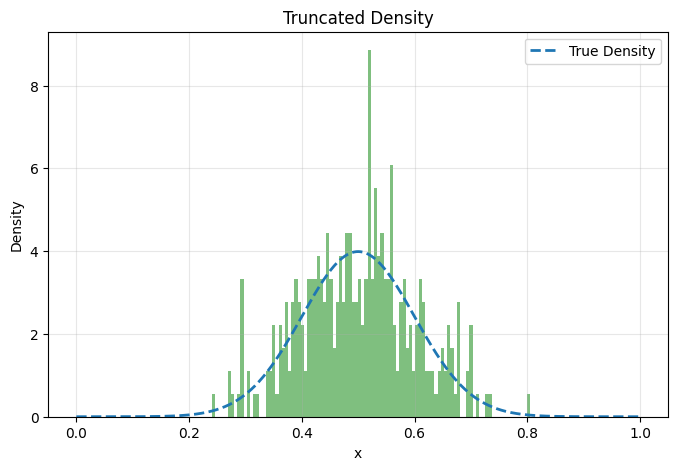

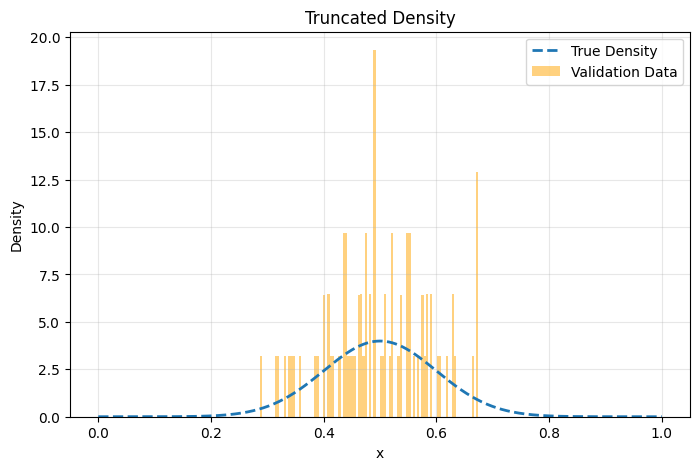

In [3]:
data_all = pd.DataFrame({
    'W1': np.concatenate([
        sampler.generate_samples(n_samples)
    ])
})

# cut data into training and validation sets
data = data_all[:4 * n_samples // 5]
data_val = data_all[4 * n_samples // 5:]

# plot the density of the data and the true density
density_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    title="Truncated Density",
    method_label="True Density",
    show=False
)
ax = density_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data",
    color="green"
)
density_plot.show()

# plot the density of the data
density_plot = plot_density(
    grid_points=np.linspace(0, 1, 1000),
    true_density=sampler.compute_density(
        np.linspace(0, 1, 1000)
    ),
    title="Truncated Density",
    method_label="True Density",
    show=False
)
ax = density_plot.gca()
# show validation data
ax.hist(
    data_val["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Validation Data",
    color="orange"
)
ax.legend()
density_plot.show()

In [4]:
from cross_validation.optuna_hyperparam_selector import OptunaHyperparameterTuner

tuner = OptunaHyperparameterTuner('CVXPYEstimator', data, sampler_setup, cv_folds=5, metric='sll', silent=True, show_progress=True)
res = tuner.optimize(n_trials=100, show_progress=False)
print('Best params:', res['best_params']); print('Best CV:', res['best_metric_value'])

best_est = tuner.fit_best_model()

Optimizing CVXPYEstimator: 100%|██████████| 100/100 [04:59<00:00,  3.00s/trial, Best SLL: 0.8748]


Best params: {'basis_order': 2, 'norm_constraint': 73.49966529316575}
Best CV: 0.8747985554290226


In [5]:
estimator_params = {
    'basis_order': getattr(best_est, 'basis_order', 0),
    'norm_constraint': getattr(best_est, 'norm_constraint', 1e3),
}
print('Estimator params:', estimator_params)

Estimator params: {'basis_order': 2, 'norm_constraint': 73.49966529316575}


Fitting CVXPYEstimator ...
Finished fitting CVXPYEstimator ...


<Figure size 2000x1500 with 0 Axes>

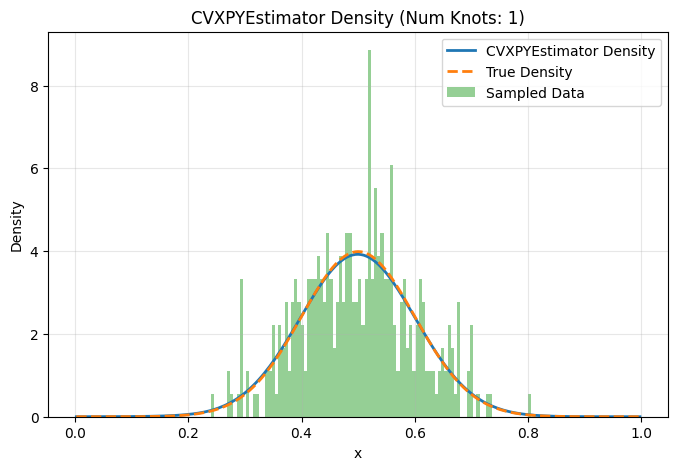

In [4]:
# define all estimator params in one place
# estimator_params = {
#     "k": 2,
#     "lam": 1e4,
# }

estimator_params = {
    "basis_order": 2,
    "norm_constraint": 73.49966529316575
}

# unpack into the constructor
estimator = CVXPYEstimator(**estimator_params)
# estimator = TrendFilteringCVXPYEstimator(**estimator_params)

estimator_setup = {
    "estimator": estimator.__class__.__name__,
    "estimator_params": estimator_params,
}

result_fpath = f"local/tmp_results/estimation/estimation_{sampler.__class__.__name__}_results_{estimator.__class__.__name__}_order_{estimator.basis_order}.json"
# result_fpath = f"local/tmp_results/estimation/estimation_{sampler.__class__.__name__}_results_{estimator.__class__.__name__}_k_{estimator.k}_lam_{estimator.lam}.json"


fit_params = {
    'data': data,
    # 'validation_data': data_val,
    # 'validation_frequency': -1,  # no validation
}


# fitting the estimator
print(f"Fitting {estimator.__class__.__name__} ...")
estimator.fit(**fit_params)
print(f"Finished fitting {estimator.__class__.__name__} ...")

# Get results
grid_points, estimated_density = estimator.get_density()
estimation_results = estimator.get_results()

plt.figure(figsize=(20, 15))

# Compute true density vs estimated density for comparison
density_plot = plot_density(
    grid_points=grid_points,
    true_density=sampler.compute_density(grid_points),
    estimated_density=estimated_density,
    title=f"{estimator.__class__.__name__} Density (Num Knots: {estimation_results.get('n_selected_knots', 'N/A')})",
    method_label=f"{estimator.__class__.__name__} Density",
    show=False
)
# add data["W1"].hist(bins=100, density=True, alpha=0.5) to the plot
ax = density_plot.gca()
ax.hist(
    data["W1"], 
    bins=100, 
    density=True, 
    alpha=0.5, 
    label="Sampled Data"
)
ax.legend()
density_plot.show()

if not os.path.exists("local/tmp_results/estimation"):
    os.makedirs("local/tmp_results/estimation")

# save results to json
with open(result_fpath, "w") as f:
    json.dump({
        "sampler_setup": sampler_setup,
        "estimator_setup": estimator_setup,
        "results": serialize_dict_to_json(estimation_results),
        "fit_params": serialize_dict_to_json(fit_params),
        }, f, indent=4
    )

In [5]:
# First, let's debug the issue by adding some print statements
print(f"Number of data points: {len(data)}")
print(f"Data range: [{data['W1'].min():.3f}, {data['W1'].max():.3f}]")

Number of data points: 320
Data range: [0.240, 0.805]


Loading results from local/tmp_results/estimation/estimation_TruncatedNormal_results_CVXPYEstimator_order_2.json ...
Keys in estimation_results:
  sampler_setup: <class 'dict'>
  estimator_setup: <class 'dict'>
  results: <class 'dict'>
  fit_params: <class 'dict'>
Step 1: Computing covariance matrix of beta...
Covariance matrix shape: (4, 4)
Covariance matrix computed successfully!
Matrix condition number: inf

Step 2: Setting up evaluation points...
Evaluating density variance at 100 points

Step 3: Computing confidence intervals...
Confidence intervals computed for 100 points
Average standard error: 0.0300
Average interval width: 0.1174


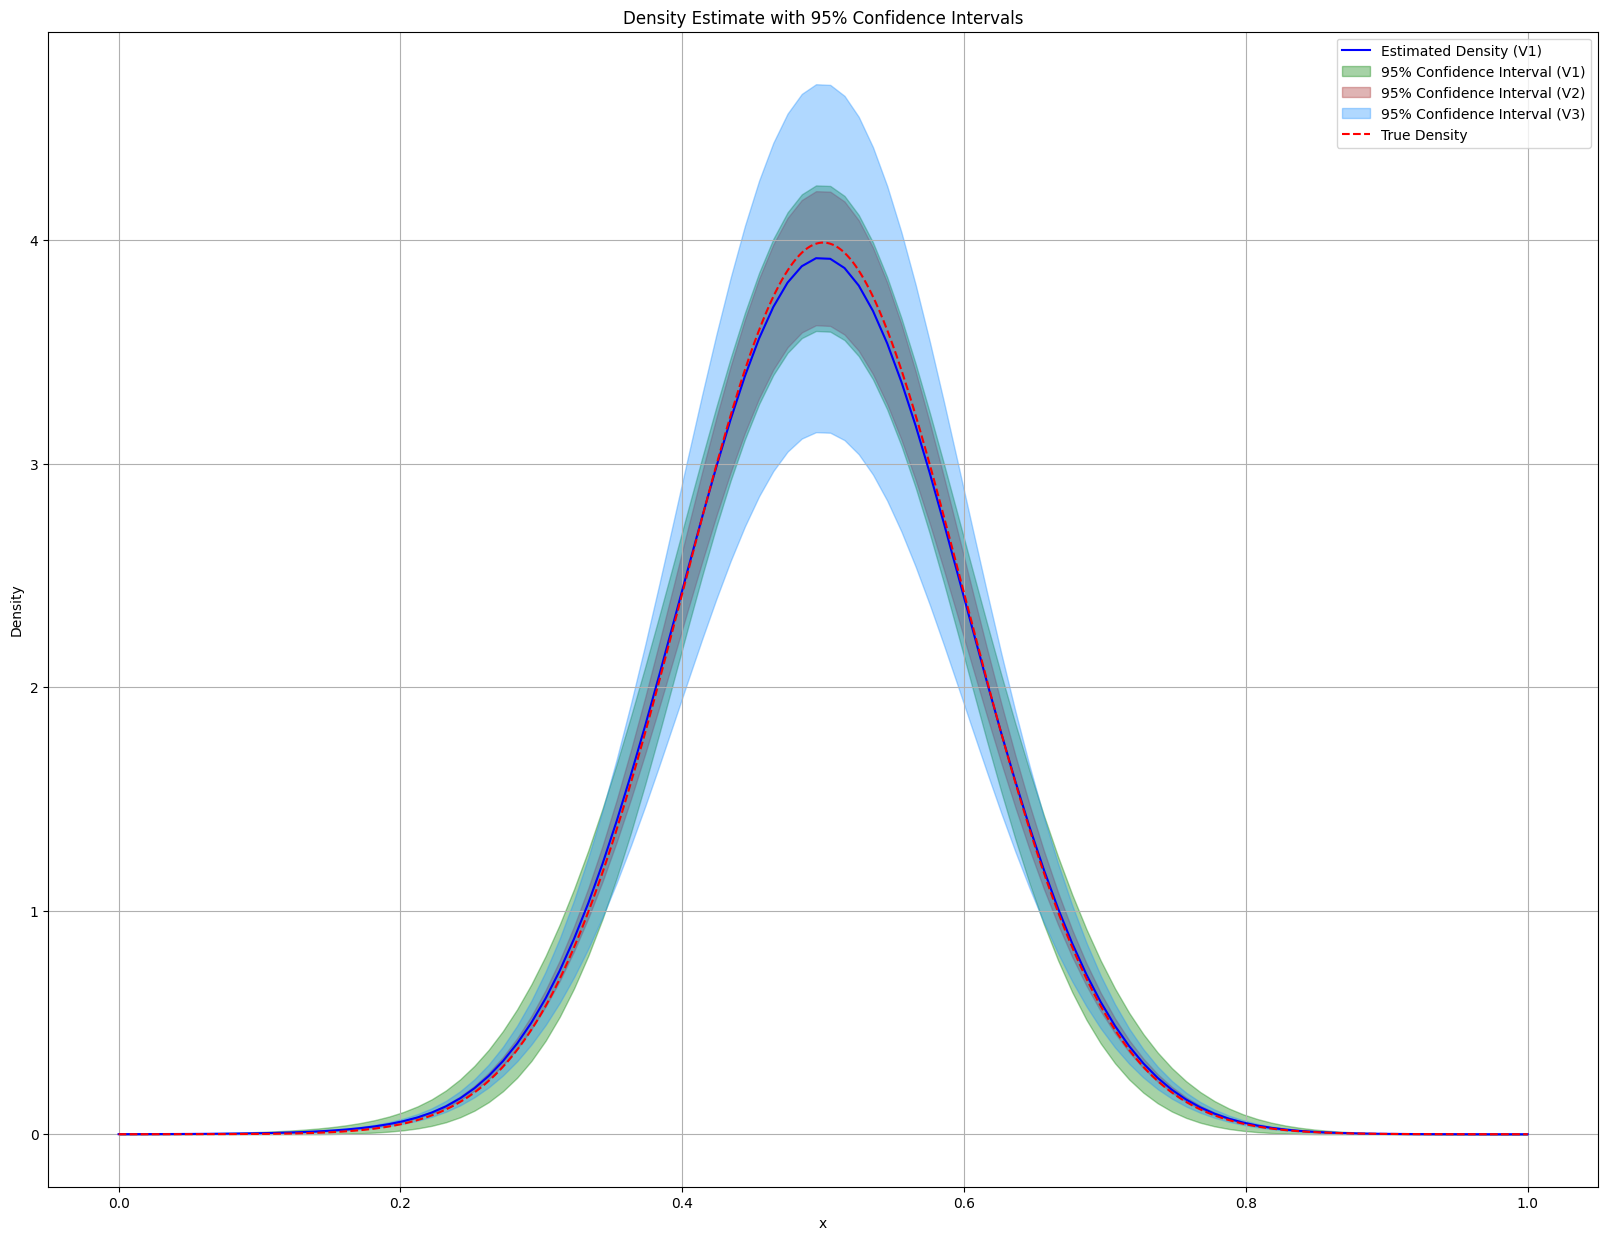

Average upper CI difference: -0.055992979767
Upper CI difference range: [-0.168892158939, -0.000040595690]
Average lower CI difference: 0.055838598875
Lower CI difference range: [0.000019729449, 0.168892158939]


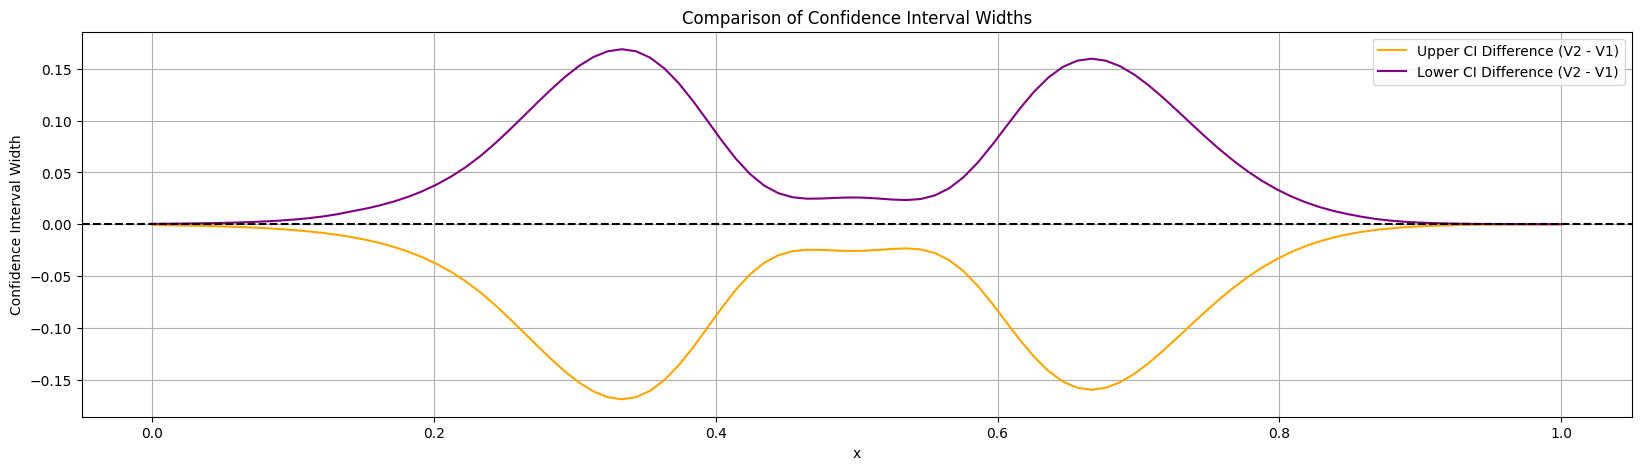

In [19]:
# if results are not saved, save them
if os.path.exists(result_fpath):
    # load results from json
    fname = f"local/tmp_results/estimation/estimation_{sampler.__class__.__name__}_results_{estimator.__class__.__name__}_order_{estimator.basis_order}.json"
    print(f"Loading results from {fname} ...")
    with open(fname, "r") as f:
        loaded_results = json.load(f)
    estimation_results = loaded_results

# Check what keys are available in estimation_results
print("Keys in estimation_results:")
for key in estimation_results.keys():
    print(f"  {key}: {type(estimation_results[key])}")
    if isinstance(estimation_results[key], (list, np.ndarray)):
        if hasattr(estimation_results[key], 'shape'):
            print(f"    Shape: {estimation_results[key].shape}")
        else:
            print(f"    Length: {len(estimation_results[key])}")

# =============================================================================
# DENSITY VARIANCE COMPUTATION DEMONSTRATION
# =============================================================================

# Import the necessary functions from density_variance
from density_variance.density_variance_v2 import (
    estimate_covariance_beta,
    density_confidence_interval
)

# Step 1: Compute the covariance matrix of beta
print("Step 1: Computing covariance matrix of beta...")
cov_beta = estimate_covariance_beta(data, estimation_results)
print(f"Covariance matrix shape: {cov_beta.shape}")
print(f"Covariance matrix computed successfully!")
print(f"Matrix condition number: {np.linalg.cond(cov_beta):.2e}")

# Step 2: Define evaluation points for density variance and confidence intervals
print("\nStep 2: Setting up evaluation points...")
x_values = np.linspace(0, 1, 100)
print(f"Evaluating density variance at {len(x_values)} points")

# Step 3: Compute confidence intervals for the density estimates
print("\nStep 3: Computing confidence intervals...")
ci_df = density_confidence_interval(x_values, estimation_results, cov_beta, alpha=0.05)
print(f"Confidence intervals computed for {len(ci_df)} points")
print(f"Average standard error: {ci_df['se'].mean():.4f}")
print(f"Average interval width: {(ci_df['upper'] - ci_df['lower']).mean():.4f}")



from density_variance.density_variance import (
    estimate_covariance_beta as estimate_covariance_beta_v1,
    density_confidence_interval as density_confidence_interval_v1
)

from density_variance.density_variance_v2 import (
    estimate_covariance_beta as estimate_covariance_beta_v2,
    density_confidence_interval as density_confidence_interval_v2
)

from density_variance.density_variance_v3 import (
    estimate_covariance_beta as estimate_covariance_beta_v3,
    density_confidence_interval as density_confidence_interval_v3
)



# (This will use all observations in full data.)
cov_beta_v1 = estimate_covariance_beta_v1(data, estimation_results, ridge_param=1e-5)
cov_beta_v2 = estimate_covariance_beta_v2(data, estimation_results, ridge_param=1e-5)
cov_beta_v3 = estimate_covariance_beta_v3(data, estimation_results, ridge_param=1e-3)

# Define evaluation points (for example, 100 equally spaced points between 0 and 1):
x_vals = np.linspace(0, 1, 100)

# Compute confidence intervals for the density estimates:
ci_df_v1 = density_confidence_interval_v1(x_vals, estimation_results, cov_beta_v1, alpha=0.05)
ci_df_v2 = density_confidence_interval_v2(x_vals, estimation_results, cov_beta_v2, alpha=0.05, ridge_param=1e-5)
ci_df_v3 = density_confidence_interval_v3(x_vals, estimation_results, cov_beta_v3, alpha=0.05, ridge_param=1e-3)

# Plot the results:
plt.figure(figsize=(20,15))
plt.plot(ci_df_v1['x'], ci_df_v1['density'], label='Estimated Density (V1)', color='blue')
plt.fill_between(ci_df_v1['x'], ci_df_v1['lower'], ci_df_v1['upper'], color='green', alpha=0.35,
                 label='95% Confidence Interval (V1)')
plt.fill_between(ci_df_v2['x'], ci_df_v2['lower'], ci_df_v2['upper'], color='brown', alpha=0.35,
                 label='95% Confidence Interval (V2)')
plt.fill_between(ci_df_v3['x'], ci_df_v3['lower'], ci_df_v3['upper'], color='dodgerblue', alpha=0.35,
                 label='95% Confidence Interval (V3)')
# plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Training Data Histogram', color='green')
plt.plot(np.linspace(0, 1, 1001), sampler.compute_density(np.linspace(0, 1, 1001)), label='True Density', color='red', linestyle='--')
plt.legend()    
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.legend()
plt.grid()
plt.show()

# Plot the differenrce between the two confidence intervals
ci_df_upper_diff = ci_df_v2['upper'] - ci_df_v1['upper']
ci_df_lower_diff = ci_df_v2['lower'] - ci_df_v1['lower']
print(f"Average upper CI difference: {ci_df_upper_diff.mean():.12f}")
print(f"Upper CI difference range: [{ci_df_upper_diff.min():.12f}, {ci_df_upper_diff.max():.12f}]")
print(f"Average lower CI difference: {ci_df_lower_diff.mean():.12f}")
print(f"Lower CI difference range: [{ci_df_lower_diff.min():.12f}, {ci_df_lower_diff.max():.12f}]")
plt.figure(figsize=(20,5))
plt.plot(ci_df_v1['x'], ci_df_upper_diff, label='Upper CI Difference (V2 - V1)', color='orange')
plt.plot(ci_df_v1['x'], ci_df_lower_diff, label='Lower CI Difference (V2 - V1)', color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.legend()
plt.xlabel('x')
plt.ylabel('Confidence Interval Width')
plt.title('Comparison of Confidence Interval Widths')
plt.legend()
plt.grid()
plt.show()

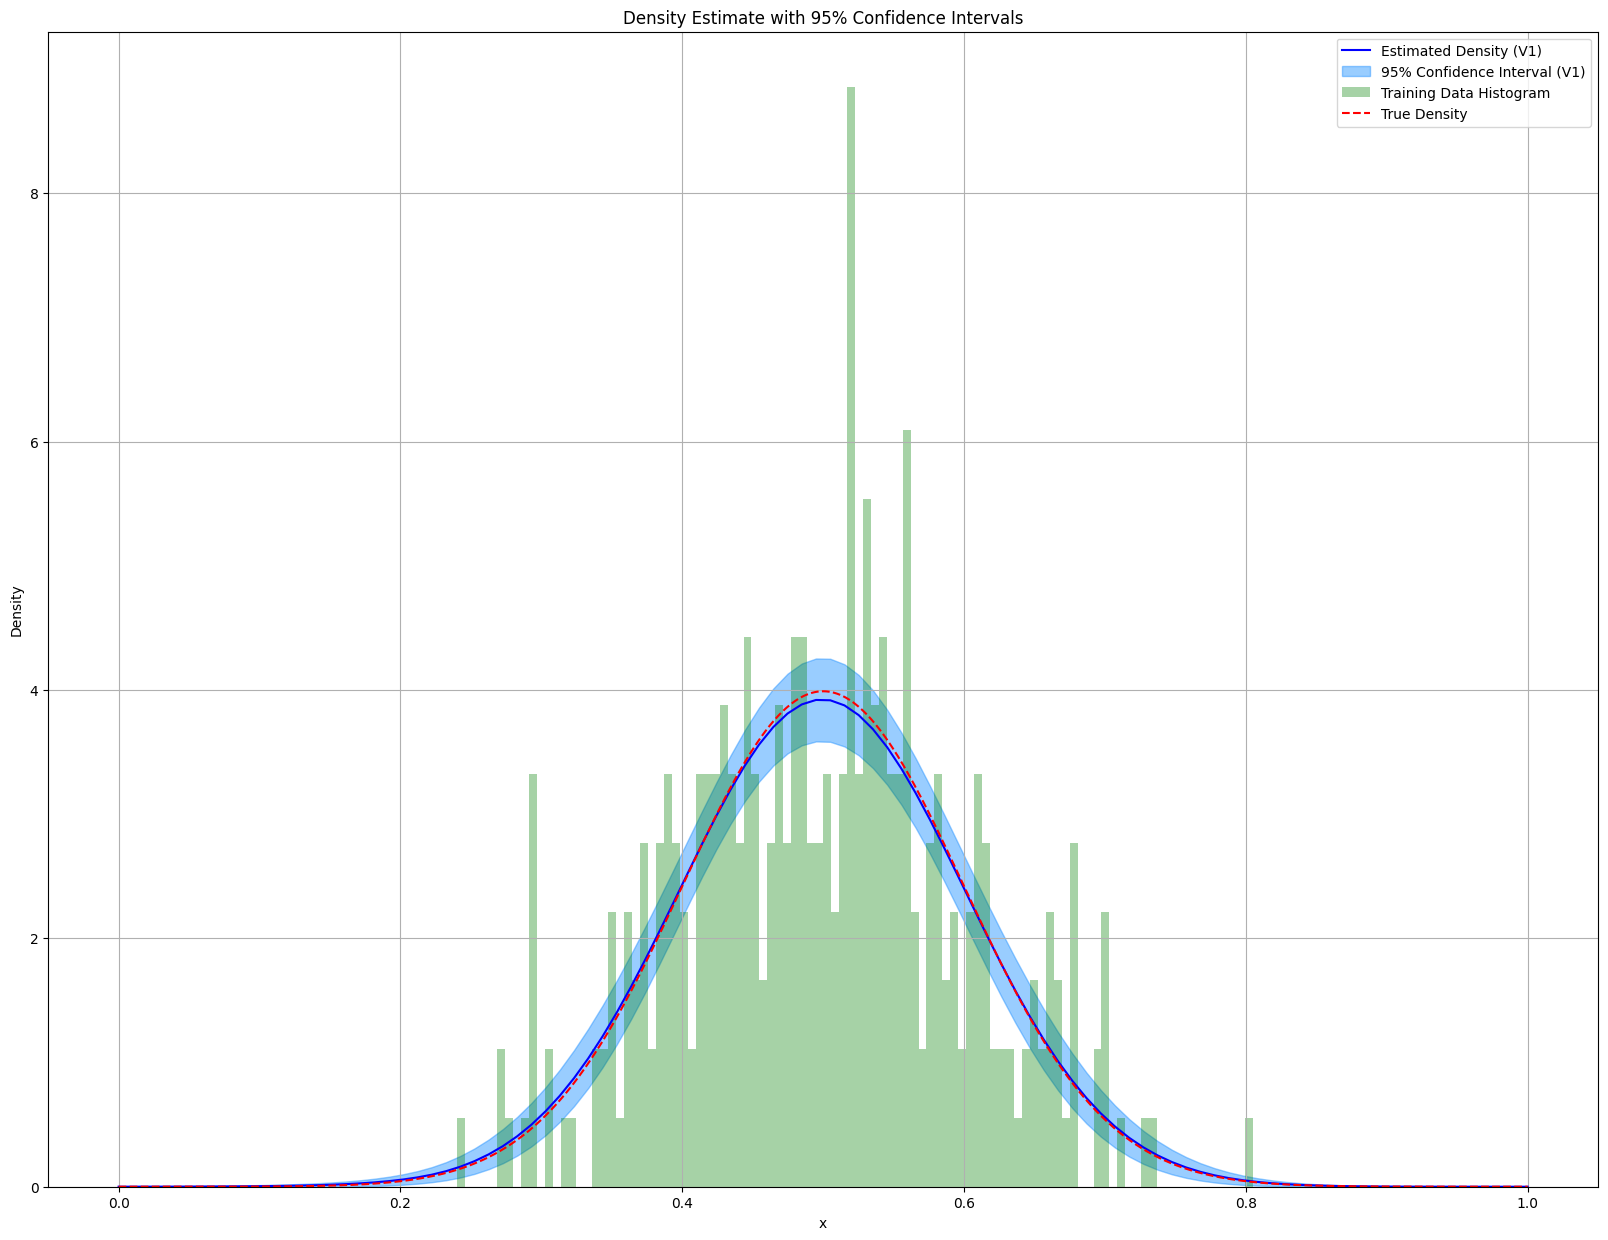

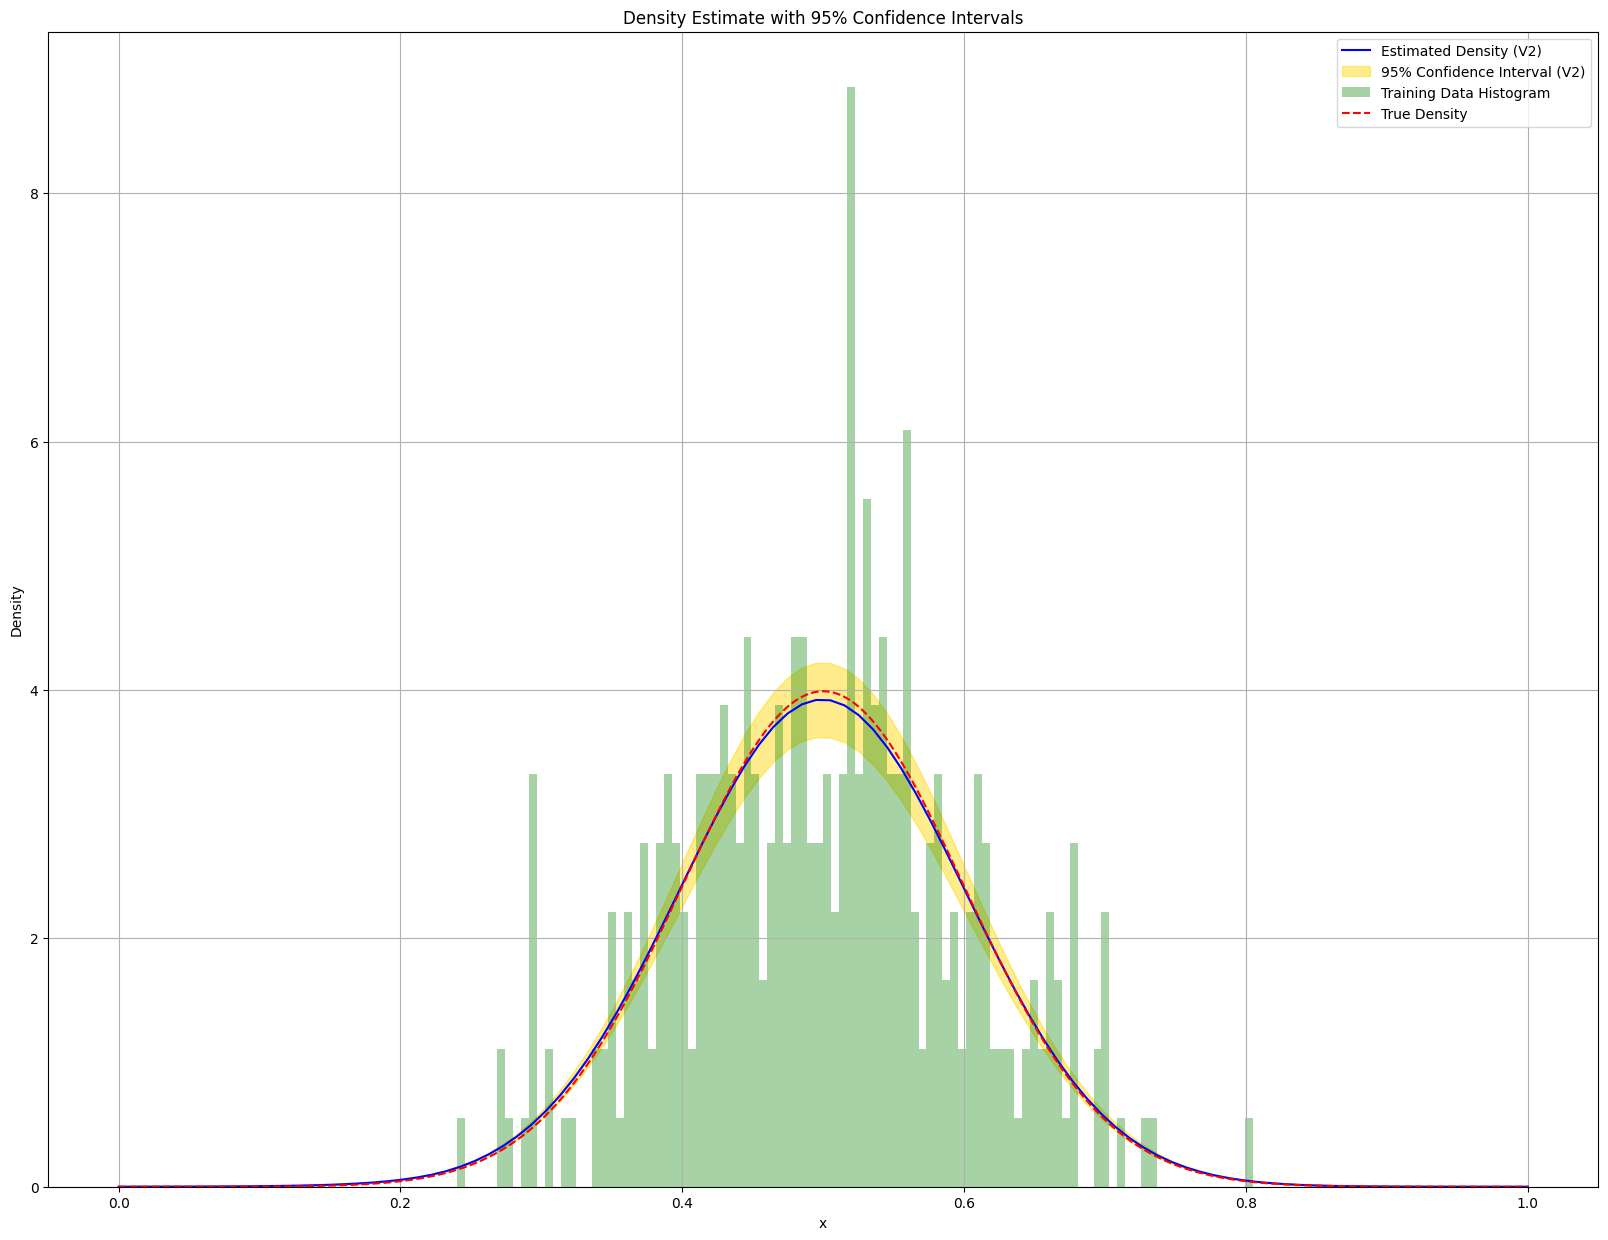

In [7]:
# Plot the results:
plt.figure(figsize=(20,15))
plt.plot(ci_df_v1['x'], ci_df_v1['density'], label='Estimated Density (V1)', color='blue')
plt.fill_between(ci_df_v1['x'], ci_df_v1['lower'], ci_df_v1['upper'], color='dodgerblue', alpha=0.45,
                 label='95% Confidence Interval (V1)')
plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Training Data Histogram', color='green')
plt.plot(np.linspace(0, 1, 1001), sampler.compute_density(np.linspace(0, 1, 1001)), label='True Density', color='red', linestyle='--')
plt.legend()    
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.legend()
plt.grid()
plt.show()

plt.figure(figsize=(20,15))
plt.plot(ci_df_v2['x'], ci_df_v2['density'], label='Estimated Density (V2)', color='blue')
plt.fill_between(ci_df_v2['x'], ci_df_v2['lower'], ci_df_v2['upper'], color='gold', alpha=0.45,
                 label='95% Confidence Interval (V2)')
plt.hist(data['W1'], bins=100, density=True, alpha=0.35, label='Training Data Histogram', color='green')
plt.plot(np.linspace(0, 1, 1001), sampler.compute_density(np.linspace(0, 1, 1001)), label='True Density', color='red', linestyle='--')
plt.legend()    
plt.xlabel('x')
plt.ylabel('Density')
plt.title('Density Estimate with 95% Confidence Intervals')
plt.legend()
plt.grid()
plt.show()

